# Gaussian Sampling on an Infinite Domain

This notebook generates Gaussian observations, loads the trained KAN models, and evaluates their spatial generalization on a larger domain.

## 1. Imports and setup

In [84]:
import os
import sys
from datetime import datetime

from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
import plotting
import pinns
import infinite
reload(plotting)
reload(pinns)
reload(infinite)
import numpy as np
import sympy as sp
import pickle
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
from pinns import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf,build_models_KAN
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)
from plotting import plot_histories_comparison

set_seed(1)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

## 2. Generate Gaussian observations and evaluation data

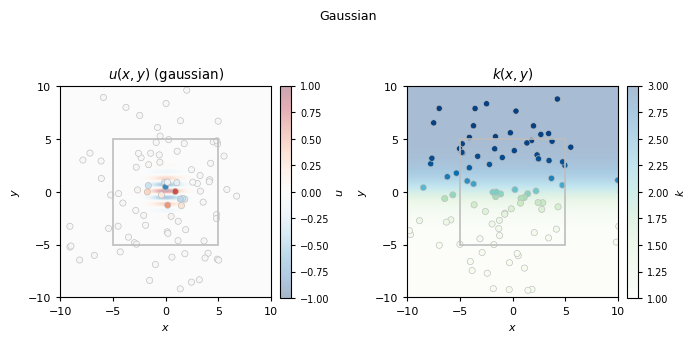

In [85]:
(
    X_obs,
    U_obs,
    X_obs_k,
    K_obs,
    X_pde,
    F_pde,
    X,
    Y,
    U,
    K,
) = generate_dataset_inf(
    sigma=5.5,
    eval_domain=(-10.0, 10.0, -10.0, 10.0),
    sampling="gaussian",
    n_obs_u=100,
    n_obs_k=100,
    n_pde=1000,
    plot=True,
    device=device,
    seed=1,
)

## 3. Load the trained KAN models

In [86]:
model_u, model_k = build_models_KAN(
    device,
    hidden_units=25,
    grid_size=5,
    spline_order=3,
)

# --------------------------------------------------
# Load trained weights
# --------------------------------------------------

run_dir = (
    "results/"
    "2026-09-01_15-50-33_gaussian_sigma5.5_adaptive_sched_no_reg"
)

model_u.load_state_dict(
    torch.load(
        f"{run_dir}/model_u.pt",
        map_location=device,
    )
)

model_k.load_state_dict(
    torch.load(
        f"{run_dir}/model_k.pt",
        map_location=device,
    )
)


<All keys matched successfully>

## 4. Evaluate spatial generalization and create the figure


Spatial generalization (MAE)
Training domain : [-5, 5] × [-5, 5]
Evaluation domain : [-10, 10] × [-10, 10]

Global MAE
u : 6.531e-03
k : 1.954e-03

Inside training domain
u : 1.384e-02
k : 1.305e-03

Outside training domain
u : 4.094e-03
k : 2.170e-03
Maximum |u_hat - u|: 0.300821
Maximum |k_hat - k|: 0.021399
Prediction plot saved to: results/gaussian_spatial_generalization.pdf


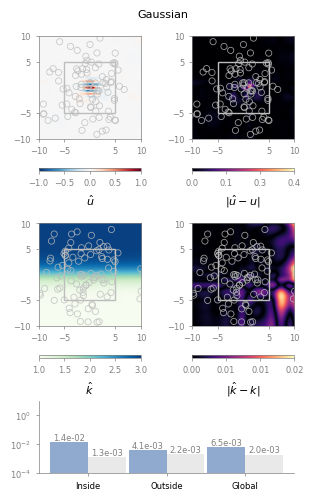

In [87]:
results = evaluate_model_inf(
    model_u=model_u,
    model_k=model_k,

    analytical_solution=analytical_solution_inf,
    coefficient=coefficient_inf,

    X_obs=X_obs,
    X_obs_k=X_obs_k,

    sampling="Gaussian",

    # Training domain
    train_xmin=-5,
    train_xmax=5,
    train_ymin=-5,
    train_ymax=5,

    # Larger domain used ONLY for evaluation
    eval_xmin=-10,
    eval_xmax=10,
    eval_ymin=-10,
    eval_ymax=10,

    n_grid=400,

    alpha=0.5,
    beta=5.0,
    epsilon=1.0,

    device=device,

    plot=True,
    verbose=True,

    save_results=False,
    results_dir="results",

    save_plot=True,
    plot_path="results/gaussian_spatial_generalization.pdf",
)

## 5. Create the two-panel sampling figure

Plot the exact fields and observations in the same compact style as the sampling-data visualization.

Sampling plot saved to: results/gaussian_sampling.pdf


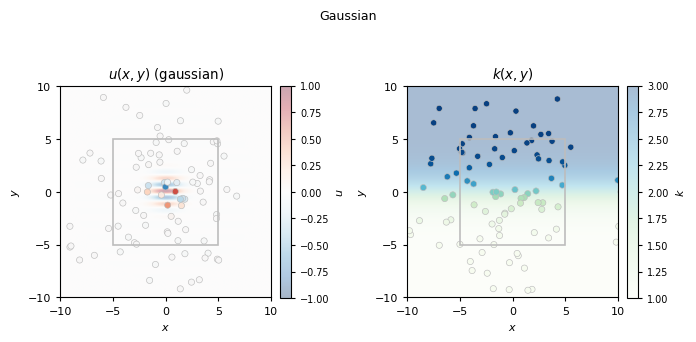

In [88]:
train_xmin, train_xmax, train_ymin, train_ymax = (-5.0, 5.0, -5.0, 5.0)
eval_xmin, eval_xmax, eval_ymin, eval_ymax = (-10.0, 10.0, -10.0, 10.0)

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.4))
extent = [eval_xmin, eval_xmax, eval_ymin, eval_ymax]

field_plots = [
    (U, X_obs, U_obs, r"$u(x,y)$ (gaussian)", "RdBu_r", -1, 1, r"$u$"),
    (K, X_obs_k, K_obs, r"$k(x,y)$", "GnBu", 1, 3, r"$k$"),
]

for axis, (field, observations, values, title, cmap, vmin, vmax, colorbar_label) in zip(axes, field_plots):
    image = axis.imshow(
        field,
        extent=extent,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        alpha=0.35,
        aspect="equal",
    )
    points = observations.detach().cpu().numpy()
    axis.scatter(
        points[:, 0],
        points[:, 1],
        c=values.detach().cpu().numpy().ravel(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        s=20,
        edgecolors="#BDBDBD",
        linewidths=0.45,
    )
    axis.add_patch(
        plt.Rectangle(
            (train_xmin, train_ymin),
            train_xmax - train_xmin,
            train_ymax - train_ymin,
            fill=False,
            edgecolor="#BDBDBD",
            linewidth=1.2,
        )
    )
    axis.set_xlim(eval_xmin, eval_xmax)
    axis.set_ylim(eval_ymin, eval_ymax)
    axis.set_title(title)
    axis.set_xlabel("$x$")
    axis.set_ylabel("$y$")
    axis.set_aspect("equal")
    axis.set_xticks([eval_xmin, -5, 0, 5, eval_xmax])
    axis.set_yticks([eval_ymin, -5, 0, 5, eval_ymax])
    axis.tick_params(labelsize=8, length=3)
    colorbar = fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    colorbar.set_label(colorbar_label, fontsize=8)
    colorbar.ax.tick_params(labelsize=7)

fig.suptitle("Gaussian", fontsize=9, y=1.02)
plt.tight_layout()
plot_path = "results/gaussian_sampling.pdf"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"Sampling plot saved to: {plot_path}")
plt.show()